In [2]:
import numpy as np
import matplotlib.pyplot as plt

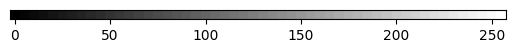

In [3]:
# Plotting greyscale images with sampled pixels
pixels = np.arange(256, dtype=np.uint8)
sampled_pixels = pixels[::5]
image = sampled_pixels[np.newaxis, :]
plt.imshow(image, cmap='gray', vmin=0, vmax=255)
# plt.axis('off')

tick_positions = np.arange(0, len(sampled_pixels), 50//5)  # every 10 original pixels
tick_labels = np.arange(0, 256, 50)
plt.xticks(tick_positions, tick_labels)
plt.yticks([])

# plt.savefig("grayscale_row.png", dpi=300, bbox_inches='tight')
plt.show()

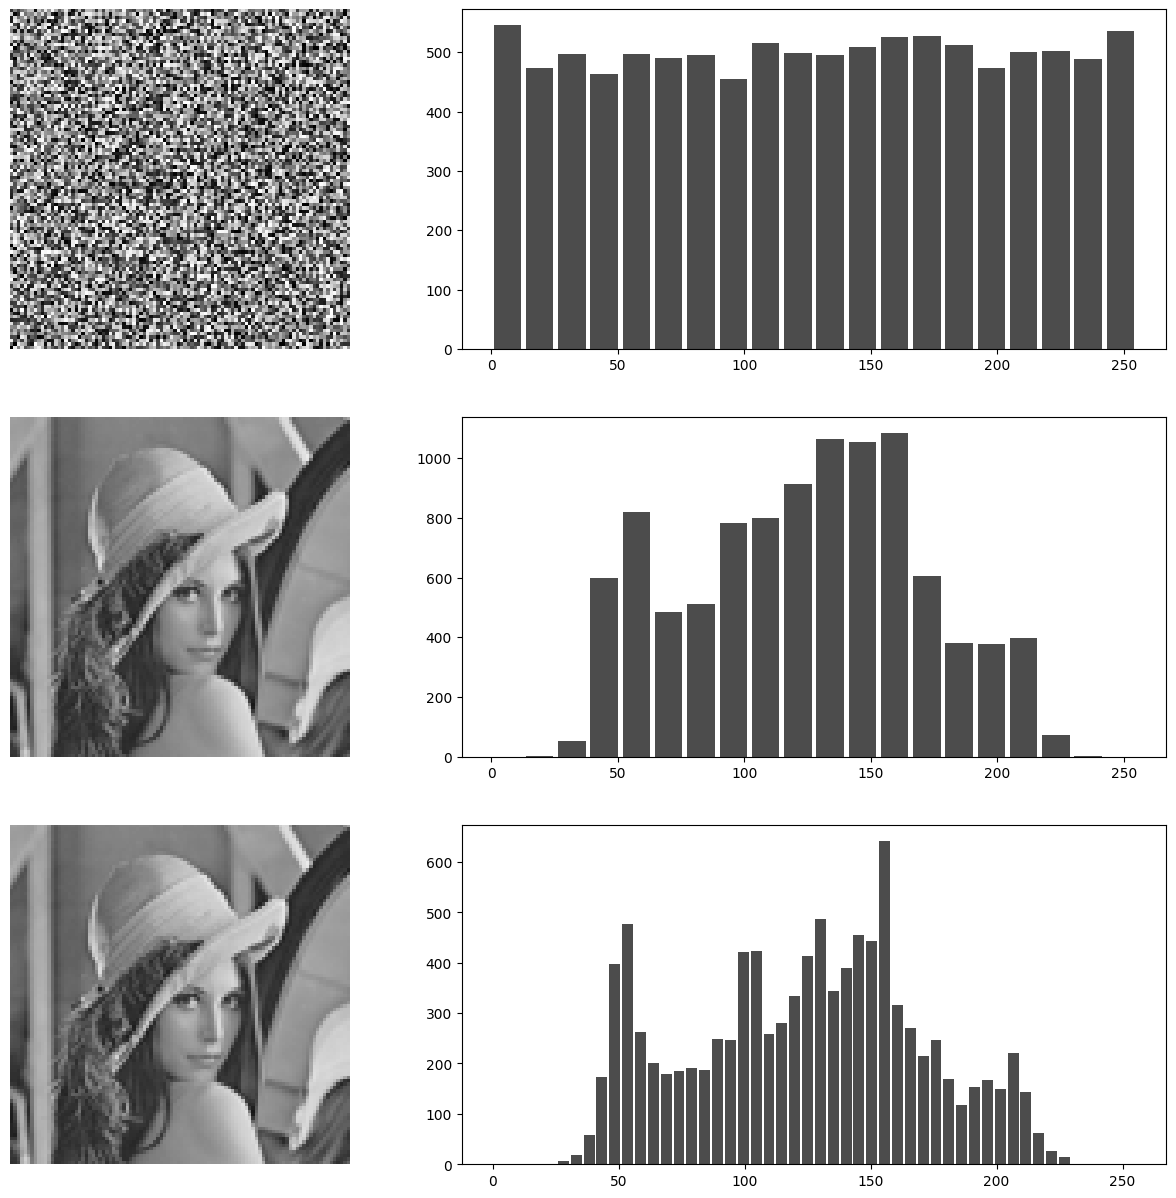

In [4]:
from matplotlib.gridspec import GridSpec
from PIL import Image
# Transforming an image to histogram
image = np.random.randint(0, 256, (100, 100), dtype=np.uint8)
lenna = Image.open('lena_std.tif').convert('L').resize((100, 100))
lenna = np.array(lenna)

# Total width = 5 + 10 = 15, height = 5
fig = plt.figure(figsize=(15, 15))

# Create a gridspec with 2 columns and widths ratio 1:2 (5 and 10)
gs = GridSpec(3, 2, width_ratios=[1, 2], figure=fig)

ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])
ax3 = fig.add_subplot(gs[3])
ax4 = fig.add_subplot(gs[4])
ax5 = fig.add_subplot(gs[5])

ax0.imshow(image, cmap='gray', vmin=0, vmax=255)
ax0.axis('off')

ax1.hist(image.ravel(), bins=20, range=(0, 255),
         color='black', alpha=0.7, rwidth=0.85)

ax2.imshow(lenna, cmap='gray', vmin=0, vmax=255)
ax2.axis('off')

ax3.hist(lenna.ravel(), bins=20, range=(0, 255),
            color='black', alpha=0.7, rwidth=0.85)

ax4.imshow(lenna, cmap='gray', vmin=0, vmax=255)
ax4.axis('off')
ax5.hist(lenna.ravel(), bins=50, range=(0, 255),
            color='black', alpha=0.7, rwidth=0.85)


# plt.savefig('histogram.png', dpi=300, bbox_inches='tight')
plt.show()

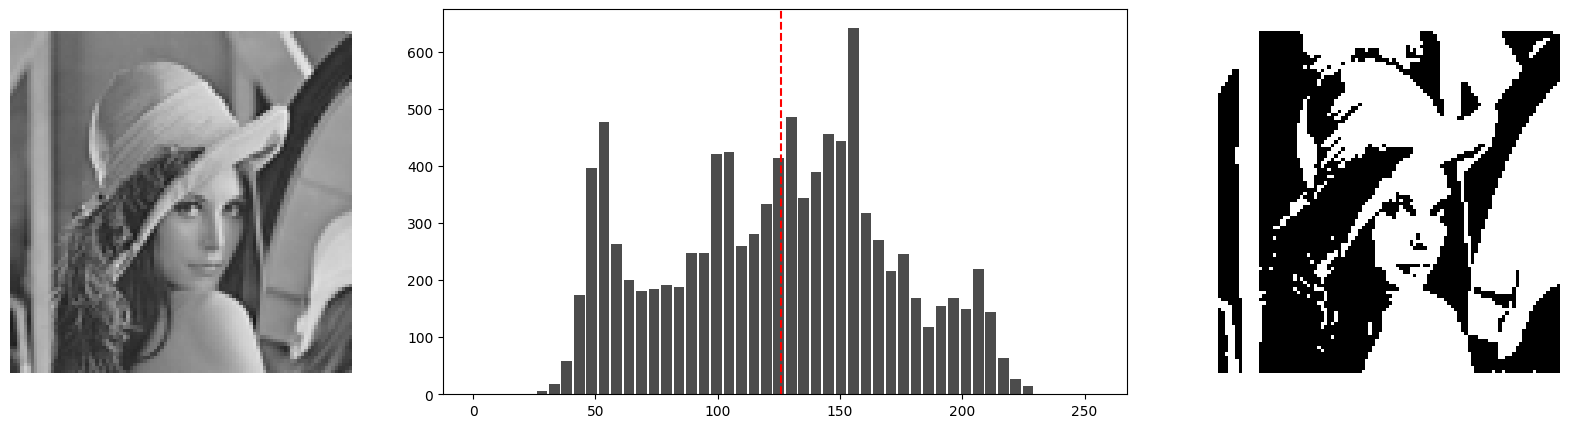

In [5]:
# Add a threshold to lenna to split the image
threshold = 126
binary_image = (lenna > threshold).astype(np.uint8)* 255

fig = plt.figure(figsize=(20, 5))
gs = GridSpec(1, 3, width_ratios=[1, 2, 1], figure=fig)

ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])

ax0.imshow(lenna, cmap='gray', vmin=0, vmax=255)
ax0.axis('off')
ax1.hist(lenna.ravel(), bins=50, range=(0, 255),
            color='black', alpha=0.7, rwidth=0.85)
ax1.vlines(threshold, 0, 1, transform=ax1.get_xaxis_transform(), color='red', linestyle='--', label='Threshold')
ax2.imshow(binary_image, cmap='gray', vmin=0, vmax=255)
ax2.axis('off')

plt.axis('off')
# plt.savefig('binary_image.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
lenna = Image.open('lena_std.tif').resize((100, 100))
lenna = np.array(lenna)
lenna.shape

(100, 100, 3)

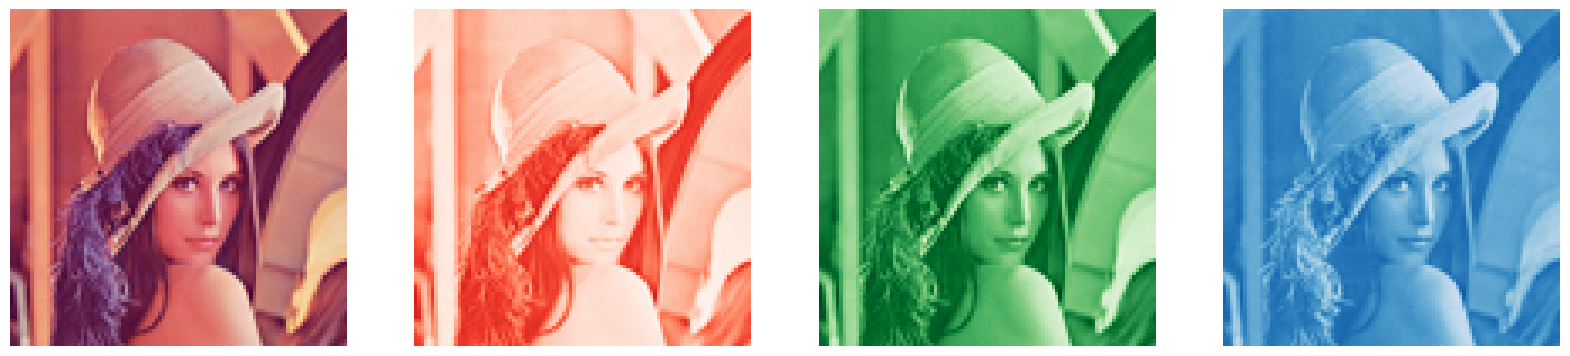

In [7]:
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(lenna)
ax[0].axis('off')
ax[1].imshow(255 - lenna[:,:, 0], cmap='Reds', vmin=0, vmax=255)
ax[1].axis('off')
ax[2].imshow(255 - lenna[:,:, 1], cmap='Greens', vmin=0, vmax=255)
ax[2].axis('off')
ax[3].imshow(255 - lenna[:,:, 2], cmap='Blues', vmin=0, vmax=255)
ax[3].axis('off')
# plt.savefig('lenna_rgb.png', dpi=300, bbox_inches='tight')
plt.show()

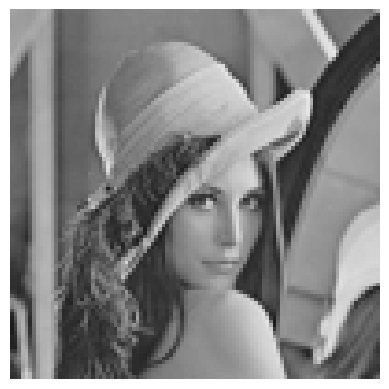

In [8]:
plt.imshow(0.3 * lenna[:, :, 0] + 0.59 * lenna[:, :, 1] + 0.11 * lenna[:, :, 2], cmap='gray', vmin=0, vmax=255)
plt.axis('off')
# plt.savefig('lenna_grey.png', dpi=300, bbox_inches='tight')
plt.show()

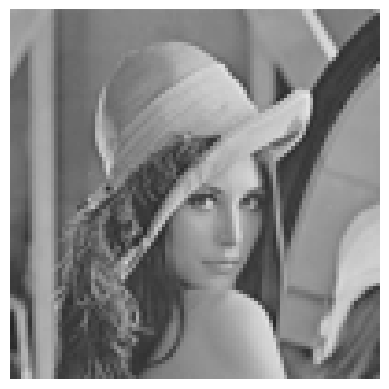

In [9]:
plt.imshow(np.mean(lenna, axis=2), cmap='gray', vmin=0, vmax=255)
plt.axis('off')
# plt.savefig('lenna_grey_mean.png', dpi=300, bbox_inches='tight
plt.show()

In [10]:
import cv2

video = cv2.VideoCapture('4K24motorwayTL3.mp4')
# Covert to grayscale
video_gray = []
for i in range(int(video.get(cv2.CAP_PROP_FRAME_COUNT))):
    ret, frame = video.read()
    if not ret:
        break
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    video_gray.append(gray_frame)
video_gray = np.array(video_gray)
video_gray.shape

(216, 1080, 1920)

In [11]:
background = []
for i in range(video_gray.shape[0]):
    if i == 0:
        background.append(video_gray[i])
    else:
        background.append(0.9 * background[i-1] + 0.1 * video_gray[i])

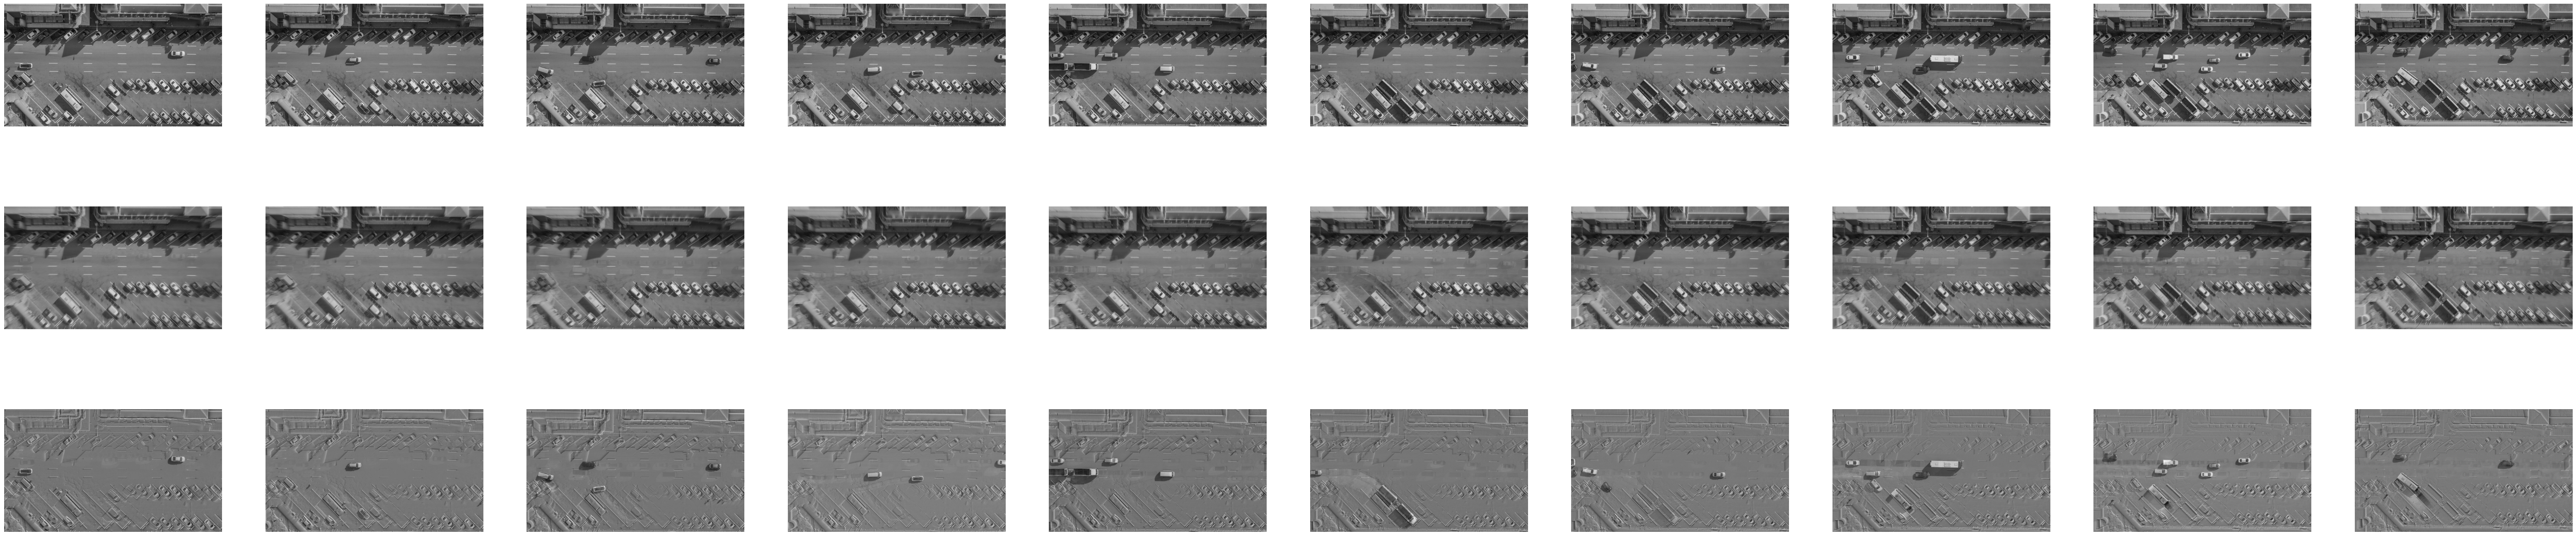

In [33]:
fig, ax = plt.subplots(3, 10, figsize=(80, 18))
for i in range(10):
    ax[0, i].imshow(video_gray[60 + i * 10], cmap='gray', vmin=0, vmax=255)
    ax[0, i].axis('off')
    ax[1, i].imshow(background[60 + i * 10], cmap='gray', vmin=0, vmax=255)
    ax[1, i].axis('off')

    diff = video_gray[60 + i * 10] - background[60 + i * 10]
    diff = np.interp(diff, (np.min(diff), np.max(diff)), (0, 255)).astype(np.uint8)

    ax[2, i].imshow(diff, cmap='gray', vmin=0, vmax=255)
    ax[2, i].axis('off')
plt.savefig('video_background.png', dpi=300, bbox_inches='tight')
plt.show()

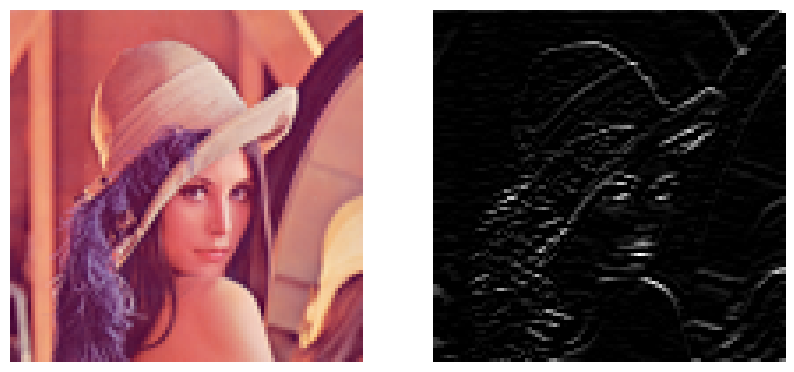

In [41]:
kernel = np.array([
    [-1, -1, -1],
    [2, 2, 2],
    [-1, -1, -1]
])
gray_lenna = cv2.cvtColor(lenna, cv2.COLOR_BGR2GRAY)
after_conv = cv2.filter2D(gray_lenna, -1, kernel)
after_conv = np.interp(after_conv, (np.min(after_conv), np.max(after_conv)), (0, 255)).astype(np.uint8)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(lenna, cmap='gray', vmin=0, vmax=255)
ax[0].axis('off')
ax[1].imshow(after_conv, cmap='gray', vmin=0, vmax=255)
ax[1].axis('off')
plt.savefig('lenna_convolution_hline.png', dpi=300, bbox_inches='tight')
plt.show()

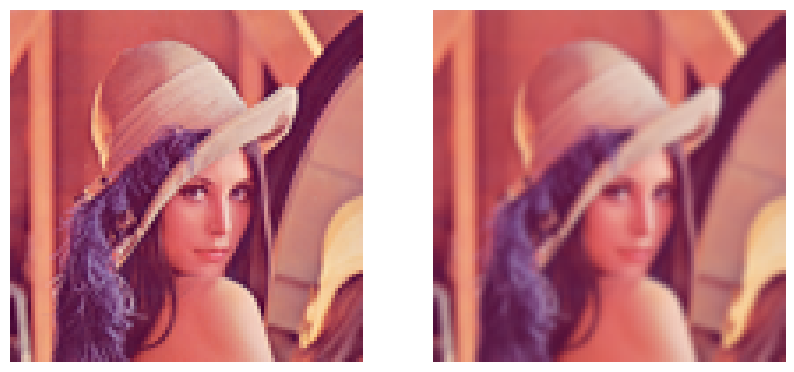

In [42]:
# A gaussian kernel that blurs the image
gaussian_kernel = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
]) / 16.0   

blurred_lenna = cv2.filter2D(lenna, -1, gaussian_kernel)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(lenna, cmap='gray', vmin=0, vmax=255)
ax[0].axis('off')
ax[1].imshow(blurred_lenna, cmap='gray', vmin=0, vmax=255)
ax[1].axis('off')
plt.savefig('lenna_blurred.png', dpi=300, bbox_inches='tight')
plt.show()  